# 🛒 ShopScope SQL Analytics
### E-commerce Sales Analysis

ShopScope SQL Analytics is a compact data analytics project that uses SQL to analyze product sales and revenue performance for an e-commerce business.

## 🎯 Project Objectives

- Analyze sales data using SQL
- Calculate total orders and revenue
- Identify top-performing products and categories
- Compare revenue performance with sales volume
- Calculate average order value
- Transform SQL results into business insights

## 🛠️ Tools & Technologies

- SQL
- SQLite
- Python
- Pandas
- Matplotlib
- Google Colab

## 📊 SQL Skills Demonstrated

- SELECT
- COUNT
- SUM
- AVG
- ROUND
- GROUP BY
- ORDER BY
- Aliases
- Calculated fields

In [1]:
import pandas as pd
import sqlite3

data = {
    "order_id": range(1, 21),
    "product": [
        "Laptop", "Headphones", "Keyboard", "Monitor", "Mouse",
        "Laptop", "Keyboard", "Headphones", "Monitor", "Mouse",
        "Laptop", "Headphones", "Keyboard", "Monitor", "Mouse",
        "Laptop", "Keyboard", "Headphones", "Monitor", "Mouse"
    ],
    "category": [
        "Computers", "Audio", "Accessories", "Displays", "Accessories",
        "Computers", "Accessories", "Audio", "Displays", "Accessories",
        "Computers", "Audio", "Accessories", "Displays", "Accessories",
        "Computers", "Accessories", "Audio", "Displays", "Accessories"
    ],
    "quantity": [1, 2, 3, 1, 4, 1, 2, 2, 1, 5, 2, 1, 4, 2, 3, 1, 5, 3, 1, 4],
    "price": [
        1200, 150, 80, 400, 40,
        1200, 80, 150, 400, 40,
        1200, 150, 80, 400, 40,
        1200, 80, 150, 400, 40
    ]
}

shopscope_df = pd.DataFrame(data)

shopscope_df

,order_id,product,category,quantity,price
0,1,Laptop,Computers,1,1200
1,2,Headphones,Audio,2,150
2,3,Keyboard,Accessories,3,80
3,4,Monitor,Displays,1,400
4,5,Mouse,Accessories,4,40
5,6,Laptop,Computers,1,1200
6,7,Keyboard,Accessories,2,80
7,8,Headphones,Audio,2,150
8,9,Monitor,Displays,1,400
9,10,Mouse,Accessories,5,40


In [2]:
conn = sqlite3.connect("shopscope.db")

shopscope_df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully!")

Database created successfully!


In [3]:
query = """
SELECT COUNT(*) AS total_orders
FROM sales;
"""

pd.read_sql_query(query, conn)

,total_orders
0,20


In [4]:
query = """
SELECT
    SUM(quantity * price) AS total_revenue
FROM sales;
"""

pd.read_sql_query(query, conn)

,total_revenue
0,10960


In [5]:
query = """
SELECT
    product,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC;
"""

pd.read_sql_query(query, conn)

,product,revenue
0,Laptop,6000
1,Monitor,2000
2,Headphones,1200
3,Keyboard,1120
4,Mouse,640


In [6]:
query = """
SELECT
    product,
    SUM(quantity) AS units_sold
FROM sales
GROUP BY product
ORDER BY units_sold DESC;
"""

pd.read_sql_query(query, conn)

,product,units_sold
0,Mouse,16
1,Keyboard,14
2,Headphones,8
3,Monitor,5
4,Laptop,5


In [7]:
query = """
SELECT
    category,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY category
ORDER BY revenue DESC;
"""

pd.read_sql_query(query, conn)

,category,revenue
0,Computers,6000
1,Displays,2000
2,Accessories,1760
3,Audio,1200


In [8]:
query = """
SELECT
    ROUND(AVG(quantity * price), 2) AS average_order_value
FROM sales;
"""

pd.read_sql_query(query, conn)

,average_order_value
0,548.0


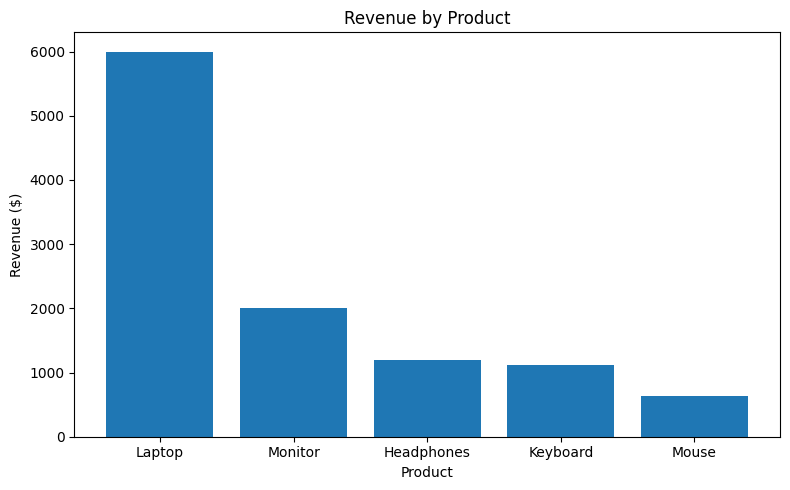

In [9]:
import matplotlib.pyplot as plt

product_revenue = pd.read_sql_query("""
SELECT
    product,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC;
""", conn)

plt.figure(figsize=(8, 5))
plt.bar(product_revenue["product"], product_revenue["revenue"])

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")

plt.tight_layout()
plt.show()

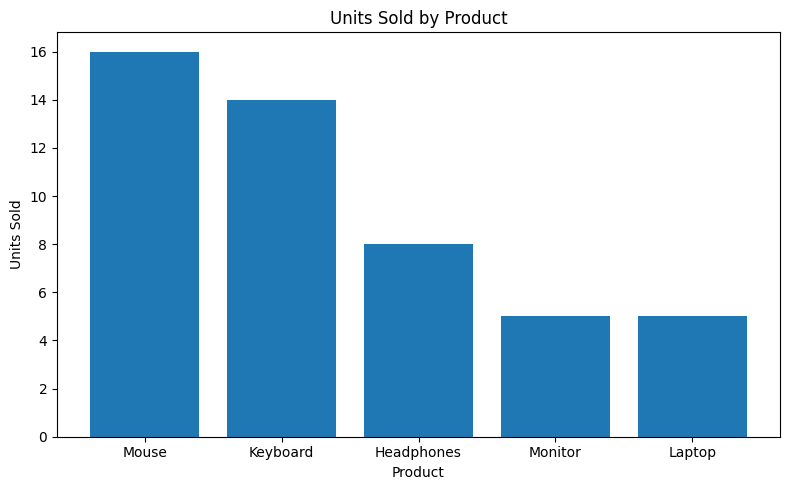

In [10]:
units_sold = pd.read_sql_query("""
SELECT
    product,
    SUM(quantity) AS units_sold
FROM sales
GROUP BY product
ORDER BY units_sold DESC;
""", conn)

plt.figure(figsize=(8, 5))
plt.bar(units_sold["product"], units_sold["units_sold"])

plt.title("Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

## Business Insights & Conclusions

The ShopScope analysis examined sales performance across products and categories using SQL.

### Key Findings

- The dataset contains **20 customer orders**.
- Total revenue reached **$10,960**.
- **Laptop** generated the highest product revenue at **$6,000**.
- **Mouse** recorded the highest sales volume with **16 units sold**.
- **Computers** was the highest-revenue category, generating **$6,000**.
- The average order value was **$548**.

### Business Insight

The analysis shows that sales volume and revenue performance are not always the same. Mouse sold the most units, while Laptop generated substantially more revenue due to its higher price.

### Recommendation

ShopScope could monitor both revenue and unit sales when evaluating product performance. High-revenue products such as Laptop can be important for overall sales value, while high-volume products such as Mouse may provide opportunities for bundles, cross-selling, or promotional strategies.
